# 02. 特徴量エンジニアリング研究

## Recruit Restaurant Visitor Forecasting

**目的**: 各特徴量の作成根拠と予測への寄与を分析する

### 分析内容
1. 特徴量の分類と設計方針
2. 時間特徴量
3. 店舗統計量
4. Rolling統計量（なぜ重要か）
5. ラグ特徴量
6. 予約情報特徴量
7. 特徴量の相関分析
8. 特徴量重要度の検証

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', 50)

SEED = 42
np.random.seed(SEED)
INPUT_DIR = Path('../input')

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

# データ読み込み
air_visit = pd.read_csv(INPUT_DIR / 'air_visit_data.csv', parse_dates=['visit_date'])
air_store = pd.read_csv(INPUT_DIR / 'air_store_info.csv')
air_reserve = pd.read_csv(INPUT_DIR / 'air_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
hpg_reserve = pd.read_csv(INPUT_DIR / 'hpg_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
store_relation = pd.read_csv(INPUT_DIR / 'store_id_relation.csv')
date_info = pd.read_csv(INPUT_DIR / 'date_info.csv', parse_dates=['calendar_date'])

print('データ読み込み完了')

データ読み込み完了


---
## 1. 特徴量の分類と設計方針

上位解法の分析から、以下の5カテゴリの特徴量が有効であることがわかっている。

| カテゴリ | 特徴量例 | 重要度 | 根拠 |
|---------|---------|--------|------|
| 時間特徴量 | 曜日、月、祝日 | ★★★ | EDAで強いパターンを確認済み |
| 店舗統計量 | 店舗平均、店舗×曜日平均 | ★★★★ | 店舗ごとの来客規模が大きく異なる |
| Rolling統計量 | 過去N日の平均・標準偏差 | ★★★★★ | 上位解法で最重要とされる |
| ラグ特徴量 | N日前の来客数 | ★★★ | 直近の傾向を反映 |
| 予約情報 | 予約人数合計 | ★★ | カバー率が低いが、ある場合は有用 |

### 設計上の注意
- **データリーク防止**: Rolling/ラグ特徴量は必ず `.shift(1)` してから計算
- **テストデータへの適用**: 統計量は学習データのみから算出
- **欠損値処理**: 予約データが無い日は0として扱う

---
## 2. ベースデータの構築

In [2]:
# 店舗情報を結合
df = air_visit.merge(air_store, on='air_store_id', how='left')
df = df.merge(
    date_info.rename(columns={'calendar_date': 'visit_date'}),
    on='visit_date', how='left'
)

# 時系列バリデーション用の分割
VALID_START = '2017-03-12'
train = df[df['visit_date'] < VALID_START].copy()
valid = df[df['visit_date'] >= VALID_START].copy()

print(f'学習: {train.shape} ({train["visit_date"].min().date()} ～ {train["visit_date"].max().date()})')
print(f'検証: {valid.shape} ({valid["visit_date"].min().date()} ～ {valid["visit_date"].max().date()})')

学習: (222073, 9) (2016-01-01 ～ 2017-03-11)
検証: (30035, 9) (2017-03-12 ～ 2017-04-22)


---
## 3. 時間特徴量の分析

EDAで確認した曜日・月パターンを特徴量化する。

In [3]:
def add_time_features(df):
    """時間特徴量を追加"""
    df = df.copy()
    df['month'] = df['visit_date'].dt.month
    df['day'] = df['visit_date'].dt.day
    df['dow'] = df['visit_date'].dt.dayofweek
    df['week'] = df['visit_date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    df['is_holiday'] = df['holiday_flg'].fillna(0).astype(int)
    return df

train_t = add_time_features(train)
valid_t = add_time_features(valid)

# 時間特徴量のみで予測
time_features = ['month', 'day', 'dow', 'week', 'is_weekend', 'is_holiday']

lgb_data = lgb.Dataset(train_t[time_features], label=np.log1p(train_t['visitors']))
model_time = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'verbose': -1, 'random_state': SEED},
    lgb_data, num_boost_round=300
)

pred = np.expm1(model_time.predict(valid_t[time_features]))
score = rmsle(valid_t['visitors'], pred)
print(f'時間特徴量のみ → RMSLE: {score:.5f}')

時間特徴量のみ → RMSLE: 0.81948


---
## 4. 店舗統計量の分析

店舗ごとの来客数は大きくばらつく。過去の統計量は強力な予測因子になる。

In [4]:
# 店舗別統計量（学習データのみから算出）
store_stats = train[train['visit_date'] < VALID_START].groupby('air_store_id')['visitors'].agg(
    ['mean', 'median', 'std', 'min', 'max', 'count']
).reset_index()
store_stats.columns = ['air_store_id', 'store_mean', 'store_median', 'store_std',
                        'store_min', 'store_max', 'store_count']

# 店舗×曜日統計量
train_dow = train.copy()
train_dow['dow'] = train_dow['visit_date'].dt.dayofweek
store_dow = train_dow.groupby(['air_store_id', 'dow'])['visitors'].agg(['mean', 'median']).reset_index()
store_dow.columns = ['air_store_id', 'dow', 'store_dow_mean', 'store_dow_median']

# ジャンル統計量（trainは既にair_genre_nameを持っているので直接groupby）
genre_stats = train.groupby('air_genre_name')['visitors'].agg(['mean', 'median']).reset_index()
genre_stats.columns = ['air_genre_name', 'genre_mean', 'genre_median']

# 結合
for d in [train_t, valid_t]:
    d['genre_encoded'] = d['air_genre_name'].factorize()[0]
    d['area_encoded'] = d['air_area_name'].factorize()[0]

train_ts = train_t.merge(store_stats, on='air_store_id', how='left')
train_ts = train_ts.merge(store_dow, on=['air_store_id', 'dow'], how='left')
train_ts = train_ts.merge(genre_stats, on='air_genre_name', how='left')

valid_ts = valid_t.merge(store_stats, on='air_store_id', how='left')
valid_ts = valid_ts.merge(store_dow, on=['air_store_id', 'dow'], how='left')
valid_ts = valid_ts.merge(genre_stats, on='air_genre_name', how='left')

# 時間 + 店舗統計で予測
store_features = time_features + [
    'genre_encoded', 'area_encoded', 'latitude', 'longitude',
    'store_mean', 'store_median', 'store_std', 'store_min', 'store_max', 'store_count',
    'store_dow_mean', 'store_dow_median', 'genre_mean', 'genre_median'
]

lgb_data2 = lgb.Dataset(train_ts[store_features], label=np.log1p(train_ts['visitors']))
model_store = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'verbose': -1, 'random_state': SEED, 'num_leaves': 63},
    lgb_data2, num_boost_round=500
)

pred2 = np.expm1(model_store.predict(valid_ts[store_features]))
score2 = rmsle(valid_ts['visitors'], pred2)
print(f'時間 + 店舗統計 → RMSLE: {score2:.5f}')
print(f'改善幅: {score - score2:.5f}')

時間 + 店舗統計 → RMSLE: 0.56187
改善幅: 0.25761


---
## 5. Rolling統計量の分析

**上位解法で最重要とされる特徴量カテゴリ。**

### なぜRolling統計量が重要か
- 店舗の**直近の来客傾向**を捉える
- 季節変動、トレンド、一時的な変化を反映
- 店舗別統計量は「全期間の平均」だが、Rolling統計量は「最近の状態」を反映

### ウィンドウサイズの選定
- **7日**: 直近1週間の傾向（短期変動）
- **14日**: 2週間の安定した傾向
- **21日**: 3週間（約1ヶ月弱）
- **35日**: 約5週間（中期傾向）
- **63日**: 約2ヶ月（季節傾向）

In [5]:
# Rolling統計量の作成（全店舗×全日付グリッド）
all_stores = df['air_store_id'].unique()
train_data = air_visit[air_visit['visit_date'] < '2017-04-23'][['air_store_id', 'visit_date', 'visitors']]
min_date = train_data['visit_date'].min()
max_date = df['visit_date'].max()
all_dates = pd.date_range(min_date, max_date, freq='D')

grid = pd.MultiIndex.from_product([all_stores, all_dates], names=['air_store_id', 'visit_date'])
grid_df = pd.DataFrame(index=grid).reset_index()
grid_df = grid_df.merge(train_data, on=['air_store_id', 'visit_date'], how='left')
grid_df = grid_df.sort_values(['air_store_id', 'visit_date']).reset_index(drop=True)

windows = [7, 14, 21, 35, 63]
for w in windows:
    grouped = grid_df.groupby('air_store_id')['visitors']
    grid_df[f'rolling_mean_{w}'] = grouped.transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    grid_df[f'rolling_std_{w}'] = grouped.transform(lambda x: x.shift(1).rolling(w, min_periods=1).std())

grid_df['ewm_mean'] = grid_df.groupby('air_store_id')['visitors'].transform(
    lambda x: x.shift(1).ewm(span=14, min_periods=1).mean()
)

# ラグ特徴量も作成
for lag in [1, 7, 14, 21, 28, 35]:
    grid_df[f'lag_{lag}'] = grid_df.groupby('air_store_id')['visitors'].shift(lag)

rolling_cols = [c for c in grid_df.columns if c.startswith(('rolling_', 'ewm_', 'lag_'))]
print(f'Rolling/ラグ特徴量: {len(rolling_cols)}個')

# メインデータに結合
train_tsr = train_ts.merge(grid_df[['air_store_id', 'visit_date'] + rolling_cols],
                            on=['air_store_id', 'visit_date'], how='left')
valid_tsr = valid_ts.merge(grid_df[['air_store_id', 'visit_date'] + rolling_cols],
                            on=['air_store_id', 'visit_date'], how='left')

Rolling/ラグ特徴量: 17個


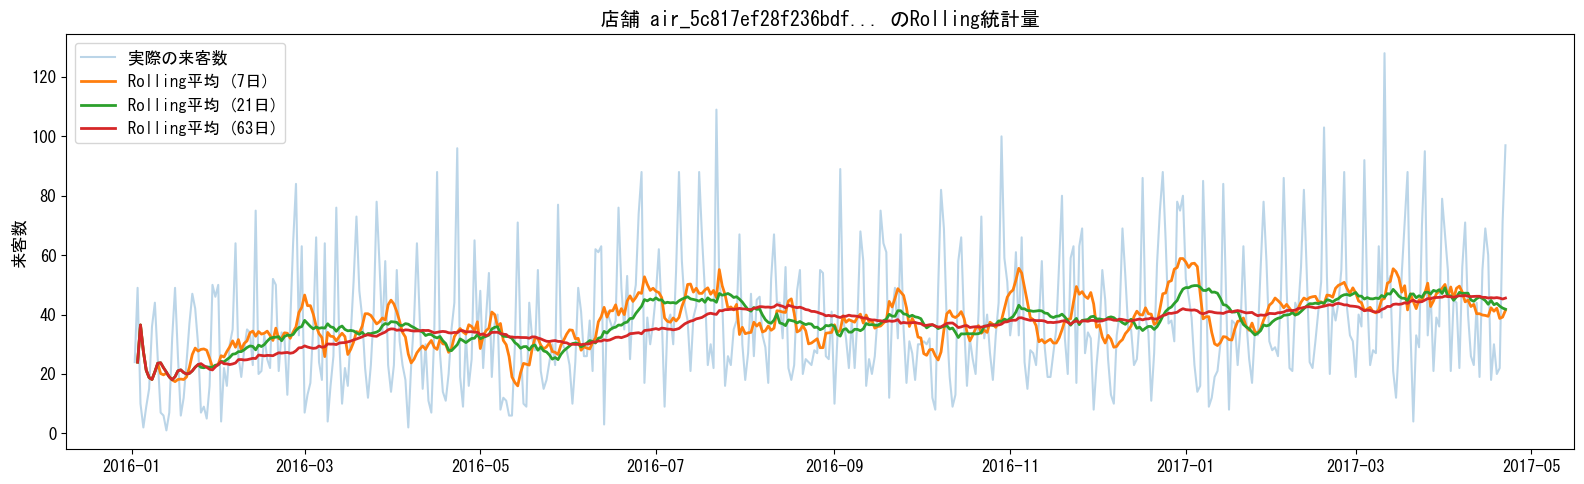

考察:
- 短い窓（7日）は変動に敏感、長い窓（63日）は安定した傾向
- 複数の窓サイズを使うことで、短期・中期・長期のパターンを捉える


In [6]:
# 特定の店舗でRolling統計量を可視化
sample_store = air_visit.groupby('air_store_id')['visitors'].count().idxmax()
sample = grid_df[grid_df['air_store_id'] == sample_store].copy()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sample['visit_date'], sample['visitors'], alpha=0.3, label='実際の来客数')
ax.plot(sample['visit_date'], sample['rolling_mean_7'], label='Rolling平均 (7日)', linewidth=2)
ax.plot(sample['visit_date'], sample['rolling_mean_21'], label='Rolling平均 (21日)', linewidth=2)
ax.plot(sample['visit_date'], sample['rolling_mean_63'], label='Rolling平均 (63日)', linewidth=2)
ax.set_title(f'店舗 {sample_store[:20]}... のRolling統計量')
ax.set_ylabel('来客数')
ax.legend()
plt.tight_layout()
plt.show()

print('考察:')
print('- 短い窓（7日）は変動に敏感、長い窓（63日）は安定した傾向')
print('- 複数の窓サイズを使うことで、短期・中期・長期のパターンを捉える')

In [7]:
# 全特徴量で予測
all_features = store_features + rolling_cols

lgb_data3 = lgb.Dataset(train_tsr[all_features], label=np.log1p(train_tsr['visitors']))
model_all = lgb.train(
    {'objective': 'regression', 'metric': 'rmse', 'verbose': -1, 'random_state': SEED,
     'num_leaves': 63, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8},
    lgb_data3, num_boost_round=1000
)

pred3 = np.expm1(model_all.predict(valid_tsr[all_features]))
score3 = rmsle(valid_tsr['visitors'], pred3)
print(f'全特徴量 → RMSLE: {score3:.5f}')
print(f'Rolling/ラグ追加による改善: {score2 - score3:.5f}')

全特徴量 → RMSLE: 0.51934
Rolling/ラグ追加による改善: 0.04253


---
## 6. 特徴量の段階的効果比較

=== 特徴量カテゴリ別の効果 ===
      特徴量セット    RMSLE  特徴量数       改善幅
        時間のみ 0.819485     6  0.000000
      + 店舗統計 0.561871    20 -0.257614
+ Rolling/ラグ 0.519338    37 -0.042533


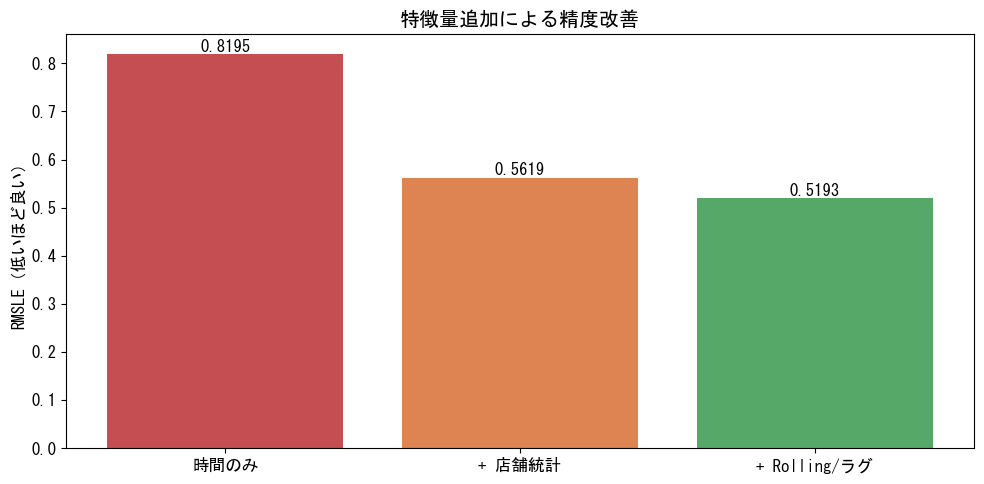

In [8]:
# 結果まとめ
results = pd.DataFrame({
    '特徴量セット': ['時間のみ', '+ 店舗統計', '+ Rolling/ラグ'],
    'RMSLE': [score, score2, score3],
    '特徴量数': [len(time_features), len(store_features), len(all_features)]
})
results['改善幅'] = results['RMSLE'].diff().fillna(0)

print('=== 特徴量カテゴリ別の効果 ===')
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(results['特徴量セット'], results['RMSLE'], color=['#C44E52', '#DD8452', '#55A868'])
for bar, val in zip(bars, results['RMSLE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=12)
ax.set_ylabel('RMSLE（低いほど良い）')
ax.set_title('特徴量追加による精度改善')
plt.tight_layout()
plt.show()

---
## 7. 特徴量重要度

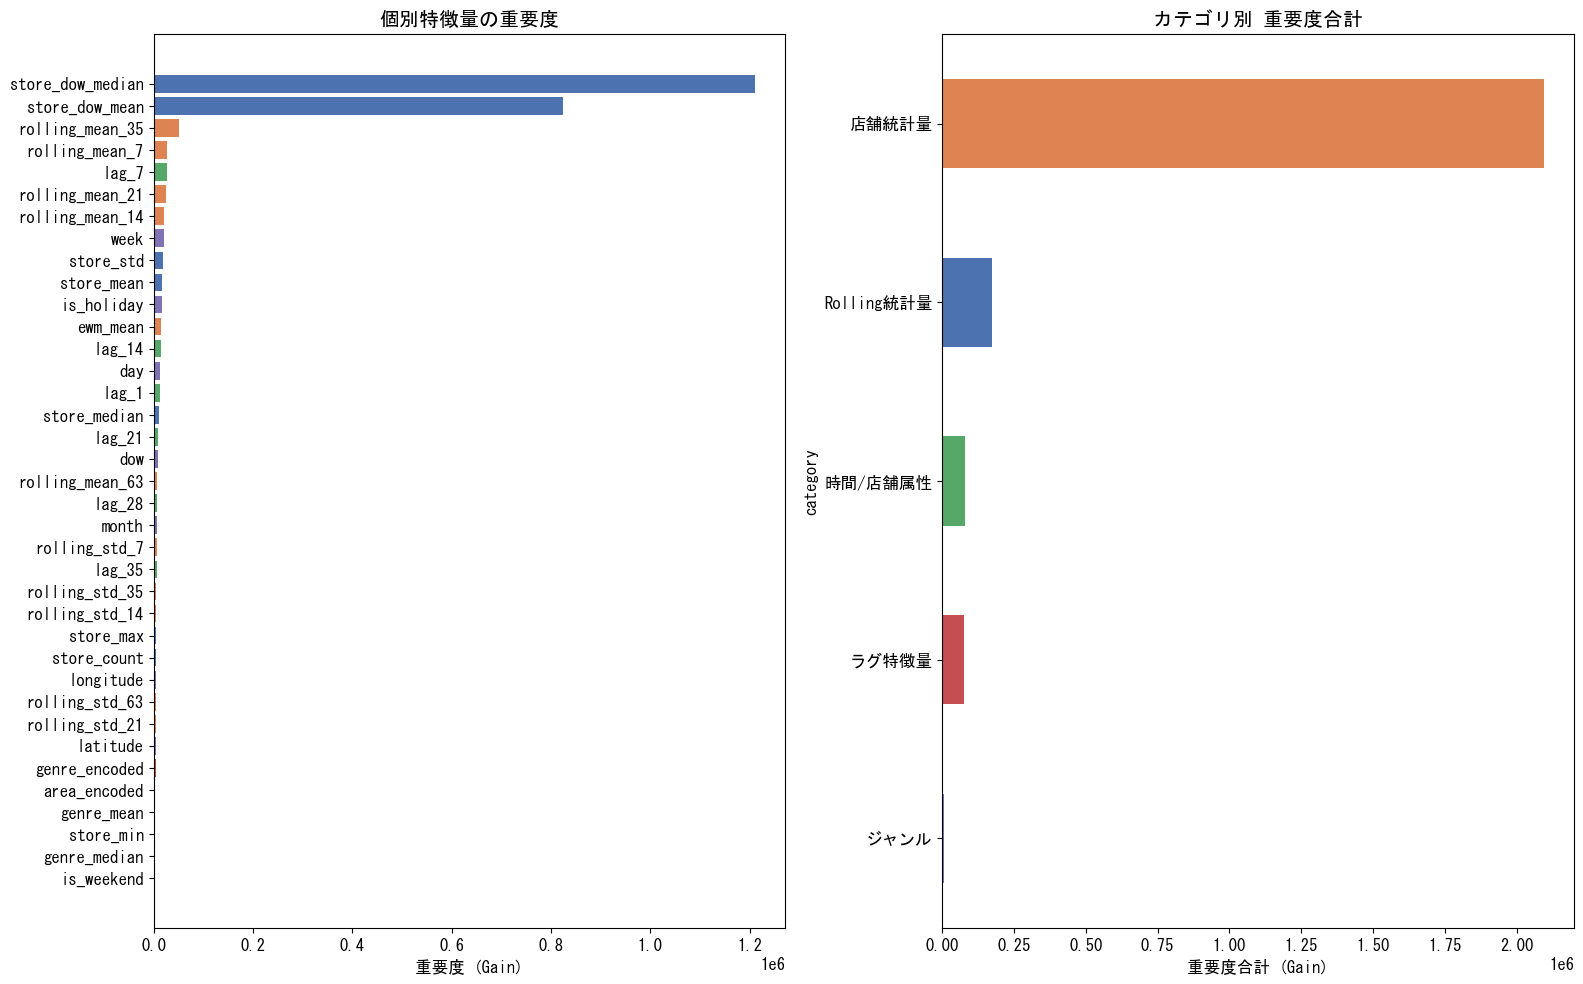


上位10特徴量:
  [店舗統計量   ] store_dow_median: 1211837
  [店舗統計量   ] store_dow_mean: 825049
  [Rolling統計量] rolling_mean_35: 51800
  [Rolling統計量] rolling_mean_7: 27336
  [ラグ特徴量   ] lag_7: 26297
  [Rolling統計量] rolling_mean_21: 25466
  [Rolling統計量] rolling_mean_14: 21431
  [時間/店舗属性 ] week: 20070
  [店舗統計量   ] store_std: 17900
  [店舗統計量   ] store_mean: 17301


In [9]:
# 特徴量重要度
importance = pd.DataFrame({
    'feature': all_features,
    'importance': model_all.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True)

# カテゴリ分け
def categorize_feature(name):
    if name.startswith('rolling_') or name.startswith('ewm_'):
        return 'Rolling統計量'
    elif name.startswith('lag_'):
        return 'ラグ特徴量'
    elif name.startswith('store_'):
        return '店舗統計量'
    elif name.startswith('genre_'):
        return 'ジャンル'
    else:
        return '時間/店舗属性'

importance['category'] = importance['feature'].apply(categorize_feature)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# 個別特徴量の重要度
colors = importance['category'].map({
    'Rolling統計量': '#DD8452', 'ラグ特徴量': '#55A868',
    '店舗統計量': '#4C72B0', 'ジャンル': '#C44E52', '時間/店舗属性': '#8172B3'
})
axes[0].barh(importance['feature'], importance['importance'], color=colors)
axes[0].set_xlabel('重要度 (Gain)')
axes[0].set_title('個別特徴量の重要度')

# カテゴリ別の合計
cat_imp = importance.groupby('category')['importance'].sum().sort_values()
cat_imp.plot(kind='barh', ax=axes[1], color=['#8172B3', '#C44E52', '#55A868', '#4C72B0', '#DD8452'])
axes[1].set_xlabel('重要度合計 (Gain)')
axes[1].set_title('カテゴリ別 重要度合計')

plt.tight_layout()
plt.show()

print('\n上位10特徴量:')
for _, row in importance.tail(10).iloc[::-1].iterrows():
    print(f'  [{row["category"]:8s}] {row["feature"]}: {row["importance"]:.0f}')

---
## 8. 相関分析

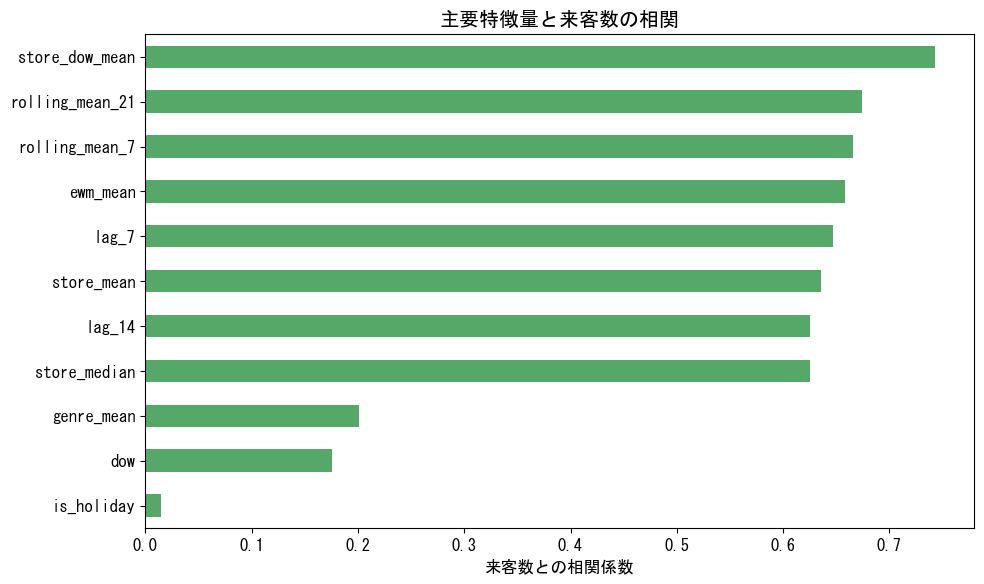

考察:
- store_dow_mean（店舗×曜日平均）が最も高い相関
- Rolling統計量も高い相関を示す
- 曜日(dow)自体は非線形なので相関係数は低いが、重要度は高い


In [10]:
# 主要特徴量と目的変数の相関
key_features = ['store_mean', 'store_dow_mean', 'store_median',
                'rolling_mean_7', 'rolling_mean_21', 'ewm_mean',
                'lag_7', 'lag_14', 'genre_mean', 'dow', 'is_holiday']

corr_data = valid_tsr[key_features + ['visitors']].corr()['visitors'].drop('visitors').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
corr_data.plot(kind='barh', ax=ax, color=['#C44E52' if v < 0 else '#55A868' for v in corr_data])
ax.set_xlabel('来客数との相関係数')
ax.set_title('主要特徴量と来客数の相関')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('考察:')
print('- store_dow_mean（店舗×曜日平均）が最も高い相関')
print('- Rolling統計量も高い相関を示す')
print('- 曜日(dow)自体は非線形なので相関係数は低いが、重要度は高い')

---
## 9. まとめ

### 特徴量エンジニアリングの結論

| 特徴量カテゴリ | 効果 | 理由 |
|--------------|------|------|
| 時間特徴量 | ベースライン | 曜日・月の周期パターンを捉える |
| 店舗統計量 | **大幅改善** | 店舗ごとの来客規模を反映 |
| Rolling/ラグ | **最大の改善** | 直近の傾向、季節変動を反映 |
| 予約情報 | 補助的 | カバー率は低いが、ある場合は有用 |

### 上位解法との一致点
- **8位解法**: Rolling統計量が最重要と報告 → 本分析でも確認
- **11位解法**: 指数加重平均を使用 → `ewm_mean` として実装
- **3位解法**: 複数ウィンドウサイズの組み合わせ → 7/14/21/35/63日を使用

### 今後の改善候補
- 天候データの追加（11位解法で効果あり）
- 近隣店舗の来客数を特徴量化
- 店舗×月の統計量追加